# Extension 3: ML-Based Anomaly Detection

**Goal:** Evaluate whether a KMeans distance-based approach detects more or fewer anomalies
than the existing Z-score method, by running both independently and comparing results
side-by-side.

**This notebook does NOT modify `src/transforms/performance/anomalies.py`.** It reads
the Z-score detections already written to `performance_anomalies` by Job 3, then runs
KMeans against the same raw `enriched_interactions.parquet` data.

**Why KMeans for anomaly detection:**
- Does not assume a Gaussian distribution
- The 99th-percentile distance threshold adapts to the actual data shape
- Can be extended to multivariate features (e.g. p50 + p95 + p99) in a future iteration

> **Note:** This feasibility notebook uses a single feature — `log_duration_ms` — rather
> than multivariate percentile aggregates. Both the Z-score method and KMeans therefore
> operate on the same individual interaction rows, making the comparison direct.

**Data sources:**
| Table | Role |
|---|---|
| `enriched_interactions.parquet` | Raw individual interactions — shared input for both methods |
| `performance_anomalies` | Existing Z-score detections (written by Job 3) for comparison |

---
**Prerequisites:** Run `make run-jobs` before opening this notebook.

## Cell 1 — Setup

In [1]:
import os
import numpy as np
import pandas as pd
import psycopg2
from pyspark.sql import SparkSession

PG = dict(
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=int(os.getenv("POSTGRES_PORT", 5432)),
    dbname=os.getenv("POSTGRES_DB", "analytics"),
    user=os.getenv("POSTGRES_USER", "analytics_user"),
    password=os.getenv("POSTGRES_PASSWORD", "analytics_pass"),
)

def pg_query(sql: str) -> pd.DataFrame:
    """Execute SQL and return a pandas DataFrame."""
    # psycopg2's context manager only manages transactions (commit/rollback),
    # NOT the connection lifecycle — close() must be called explicitly.
    conn = psycopg2.connect(**PG)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

spark = (
    SparkSession.builder
    .appName("ML Feasibility — Anomaly Detection")
    .master(os.getenv("SPARK_MASTER_URL", "spark://spark-master:7077"))
    .config("spark.driver.host", "goodnote-jupyter")
    .config("spark.driver.bindAddress", "0.0.0.0")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version, "master:", spark.sparkContext.master)

Spark 3.5.0 master: local[*]


## Cell 2 — Load Interaction Data


In [2]:
from pyspark.sql import functions as F

PARQUET_PATH = "/home/jovyan/work/data/processed/enriched_interactions.parquet"

sdf_raw = spark.read.parquet(PARQUET_PATH)
sdf_raw.cache()

row_count     = sdf_raw.count()
version_count = sdf_raw.select("app_version").distinct().count()
date_range    = sdf_raw.agg(F.min("date"), F.max("date")).collect()[0]

print(f"Rows loaded  : {row_count:,}")
print(f"App versions : {version_count}")
print(f"Date range   : {date_range[0]} \u2192 {date_range[1]}")
print()
sdf_raw.select("duration_ms").summary("count", "mean", "stddev", "min", "50%", "95%", "99%", "max").show()

Rows loaded  : 131,708
App versions : 5
Date range   : 2024-01-01 → 2024-12-30

+-------+------------------+
|summary|       duration_ms|
+-------+------------------+
|  count|            131708|
|   mean|10644.891821301668|
| stddev|26565.100664774876|
|    min|               100|
|    50%|              3281|
|    95%|             42305|
|    99%|            133072|
|    max|            300000|
+-------+------------------+



### Layman Explanation

Before building any model, the raw data tells a critical story. 131,708 interactions span five app versions across a full calendar year. The **median** interaction takes 3,281ms (~3.3 seconds) — fast enough to feel responsive. But the **95th percentile** is 42,305ms (13× the median) and the **99th percentile** is 133,072ms (40× the median). The maximum is exactly 300,000ms — a hard 5-minute ceiling built into the data generator, representing a synthetic timeout.

In practical terms: most interactions are quick, a long tail is very slow, and a handful hit an artificial ceiling. These ceiling hits will dominate the anomaly detections in later cells. On real production data, a 300,000ms request would be a genuine crisis (a 5-minute user-facing timeout); on generated data, it is a synthetic artifact injected by the generator.

### Technical Discussion

The `duration_ms` distribution reveals why preprocessing is essential before clustering:

- **Extreme right-skew:** std (26,565ms) is 2.5× the mean (10,644ms). The p50→p99 jump is 40× (3,281 → 133,072ms). This means the variance is driven almost entirely by a small number of very slow interactions.
- **Hard cap at 300,000ms:** The max equals exactly 300,000 — a synthetic ceiling, not an observed outlier. A real latency distribution would have a heavy but unbounded tail; this one has a hard wall. These capped requests will become the most extreme cluster-distance values downstream.
- **Why `log1p` is mandatory, not optional:** Without the transform, the raw feature range (100–300,000ms, a 3,000× span) would cause KMeans to place centroids near the origin and absorb 94%+ of data into a single "normal" cluster. `log1p` maps the range to (4.6–12.6), a 2.7× span — manageable for Euclidean distance. In log-space: `log1p(300000)/log1p(3281) ≈ 1.6` vs the raw ratio of 91.

The 5 app versions and full-year (2024-01-01 → 2024-12-30) date range provide enough temporal and version spread to make the downstream anomaly comparison meaningful.

### Terminology

| Term | Meaning |
|------|---------|
| **p50 / p95 / p99** | Percentile latency values — the duration below which 50%, 95%, or 99% of interactions fall. p50 represents the typical user experience; p99 shows the tail. |
| **Right-skew** | A distribution where the mean exceeds the median and a long tail extends toward large values. The signature here: mean (10,644ms) >> median (3,281ms). |
| **Hard cap** | An artificial upper limit on a value. The 300,000ms maximum is a ceiling built into the data generator — not a real-world timeout pattern. |
| **Coefficient of variation (CV)** | Standard deviation divided by mean. CV ≈ 2.5 here signals that spread far exceeds the average, indicating extreme outliers. |
| **log1p transform** | `log(1 + x)`. Compresses the wide raw range (100–300,000ms → 4.6–12.6 in log-space) so KMeans Euclidean distances are meaningful rather than dominated by a few extreme values. |

## Cell 3 — KMeans Pipeline

In [3]:
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler

null_count = sdf_raw.filter(F.col("duration_ms").isNull()).count()
if null_count > 0:
    print(f"WARNING: Dropping {null_count} rows with null duration_ms")

# Rename 'date' -> 'metric_date' and add log1p(duration_ms).
# Latency data is heavily right-skewed; log1p maps it to a near-Gaussian
# distribution so KMeans can form balanced, meaningful clusters.
sdf = (
    sdf_raw
    .dropna(subset=["duration_ms"])
    .withColumnRenamed("date", "metric_date")
    .withColumn("log_duration_ms", F.log1p(F.col("duration_ms").cast("double")))
)
sdf.cache()

PERF_COLS = ["log_duration_ms"]

assembler = VectorAssembler(inputCols=PERF_COLS, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True)
# k=3: one cluster per natural duration band — fast / normal / slow interactions.
kmeans    = KMeans(featuresCol="features", k=3, seed=42)
pipeline  = Pipeline(stages=[assembler, scaler, kmeans])

print(f"Fitting KMeans pipeline (k=3) on {sdf.count():,} individual interactions...")
model = pipeline.fit(sdf)
print("Done.")

preds_tmp = model.transform(sdf)
size_rows = preds_tmp.groupBy("prediction").count().orderBy("prediction").collect()
print("\nCluster sizes:")
for row in size_rows:
    print(f"  cluster {row['prediction']}: {row['count']:,}")
total   = sum(r["count"] for r in size_rows)
max_pct = max(r["count"] for r in size_rows) / total
if max_pct > 0.9:
    raise ValueError(
        f"Degenerate KMeans solution: largest cluster contains {max_pct:.0%} of data. "
        "Consider reducing k or adding more feature engineering before proceeding."
    )

Fitting KMeans pipeline (k=3) on 131,708 individual interactions...
Done.

Cluster sizes:
  cluster 0: 61,740
  cluster 1: 29,344
  cluster 2: 40,624


### Layman Explanation

We train a KMeans clustering model directly on the 131k individual user interactions using
`log_duration_ms` as the feature. The model discovers three natural performance bands — fast,
normal, and slow interactions — without being told where the boundaries are.

Both the KMeans and Z-score methods read the same underlying interaction data, but they answer
slightly different questions: Z-score asks *"is this interaction unusually slow compared to other
interactions on the same day for the same app version?"* (a within-group comparison). KMeans asks
*"is this interaction unusually slow compared to all interactions globally?"* (a global comparison).
Cell 7 compares their outputs at the `(metric_date, app_version)` level to see how often they agree.

### Technical Discussion

The pipeline is:
```
withColumn("log_duration_ms", log1p(duration_ms))
  → VectorAssembler(["log_duration_ms"] → features_raw)
  → StandardScaler(withMean=True → features)
  → KMeans(k=3, seed=42)
```

Training on individual interactions (same 131k rows the Z-score uses) is the critical fix
that makes the comparison meaningful. The previous version trained on the 749-row
`performance_by_version` aggregate table — a different granularity that could never produce
a fair overlap comparison with Z-score anomalies on individual events.

`log1p(duration_ms)` is applied before clustering because latency distributions are heavily
right-skewed. Without it, 94% of data collapses into a single cluster (the "normal" bucket),
leaving only two tiny outlier clusters. The log transform maps the distribution to near-Gaussian
so KMeans can form balanced, meaningful clusters. `withMean=True` then zero-centres the
log-scaled feature so distances are measured in standard-deviation units.

### Terminology

| Term | Meaning |
|------|---------|
| **Percentile latency (p50 / p95 / p99)** | The response time below which 50%, 95%, or 99% of requests fall. p50 is the typical experience; p99 reveals tail latency that affects the slowest 1% of users. |
| **StandardScaler** | Transforms each feature to have zero mean and unit variance, preventing high-magnitude features from dominating distance calculations. |
| **KMeans (k=3)** | Divides data into exactly 3 clusters — one per natural duration band (fast / normal / slow). The choice of k=3 is a design decision based on the expected structure of latency data; there is no ground truth for "correct" k in anomaly detection. |
| **Degenerate solution** | A KMeans outcome where one cluster captures nearly all points — a sign that k is too large for the data's natural structure, or that the initialisation was poor. |
| **log1p transform** | Applies `log(1 + x)` to compress heavily right-skewed data. Without it, extreme latency outliers would dominate cluster formation and collapse most data into a single "normal" cluster. |
| **Within-group Z-score** | A Z-score computed using the mean and stddev of a subgroup (here: all interactions with the same `app_version` and `metric_date`), rather than the global dataset mean and stddev. |

## Cell 4 — Centroid Distance Scoring

For each row, compute the Euclidean distance from its scaled feature vector to its assigned
cluster centroid. Rows whose distance exceeds the 99th percentile are flagged as anomalies.

In [4]:
from pyspark.ml.clustering import KMeansModel

kmeans_stage = next(s for s in model.stages if isinstance(s, KMeansModel))
centers = kmeans_stage.clusterCenters()

@F.udf("double")
def centroid_dist(features, cluster_idx):
    return float(np.linalg.norm(features.toArray() - centers[cluster_idx]))

predictions = model.transform(sdf).withColumn(
    "centroid_distance",
    centroid_dist(F.col("features"), F.col("prediction"))
)
predictions.cache()

# percentile_approx with accuracy=100_000 has error < 0.001% of row count (~1 row on 131k).
# approxQuantile(relativeError=0.01) can return the dataset maximum on a skewed tail,
# making > threshold match nothing. Use >= so rows at exactly the threshold are included.
p99_dist = predictions.select(
    F.percentile_approx("centroid_distance", 0.99, 100000)
).collect()[0][0]
print(f"99th-percentile centroid distance: {p99_dist:.4f}")

ml_anomalies = predictions.filter(F.col("centroid_distance") >= p99_dist)
print(f"ML anomalies detected: {ml_anomalies.count():,}")

99th-percentile centroid distance: 1.3669
ML anomalies detected: 1,393


### Layman Explanation

For each individual interaction, we measure **how far it sits from the centre of its cluster**.
An interaction that is very close to its cluster centre looks "typical." One that is far from any
cluster centre looks unusual — it is an outlier. We draw the line at the top 1%: any interaction
whose distance exceeds the 99th percentile of all distances is flagged as an anomaly.

This approach is **unsupervised** — we never had to manually label what "bad performance" looks
like; the model learns the normal shape of the data and flags whatever does not fit.

### Technical Discussion

`clusterCenters()` returns a Python list of NumPy arrays — one array per cluster, each with the same dimension as `features`.

The Python UDF computes the L2 (Euclidean) norm of the vector difference between a row's feature vector and its assigned centroid:

```python
distance = ‖features − centers[cluster_idx]‖₂
```

This distance is computed in **scaled feature space** (after `StandardScaler`), so it is measured in units of standard deviations, making it comparable across features.

`percentile_approx("centroid_distance", 0.99, 100_000)` computes the 99th percentile in a single distributed pass without sorting the full dataset. The `accuracy=100_000` parameter gives an approximation error of less than 0.001% of the row count (roughly 1 row on 131k) — effectively exact for this purpose. The resulting threshold is adaptive: it adjusts to the actual distribution of distances in the current dataset rather than using a fixed numeric cutoff.

The `>=` comparison (`filter(centroid_distance >= p99_dist)`) ensures that interactions landing exactly at the threshold are included. On a skewed distance tail, ties at the threshold boundary are common — using `>` instead could silently exclude them.

### Terminology

| Term | Meaning |
|------|---------|
| **Euclidean distance (L2 norm)** | The straight-line distance between two points: `√(Σ(aᵢ − bᵢ)²)`. Also written `‖a − b‖₂`. |
| **Python UDF** | User Defined Function — custom Python logic registered with Spark. Each row is serialised from JVM to Python, processed, and serialised back. This is slower than native Spark operations but necessary for arbitrary Python/NumPy logic like NumPy array arithmetic. |
| **Closure** | A function that "remembers" variables from the scope in which it was defined. Here `centroid_dist` closes over `centers` — the list of cluster centres from the trained model. |
| **`percentile_approx`** | A Spark SQL function that estimates a quantile (e.g. 99th percentile) in a single distributed pass using a sketch algorithm. The `accuracy` parameter controls precision — higher values give smaller errors. At `accuracy=100_000` the error is < 0.001% of total row count. |
| **Adaptive threshold** | A threshold derived from the data itself (here the 99th percentile of distances) rather than set manually. It automatically adjusts when the data distribution changes. |
| **Unsupervised anomaly detection** | Finding anomalies without labelled examples of "anomaly" vs "normal." The model infers normality from the structure of the data. |
| **Scaled feature space** | The coordinate system after applying StandardScaler, where each axis is in units of standard deviations rather than the original units (ms, counts, etc.). |

## Cell 5 — KMeans Anomaly Details

In [5]:
ml_pd = (
    ml_anomalies
    .select("metric_date", "app_version", "centroid_distance", "duration_ms")
    .orderBy(F.col("centroid_distance").desc())
    .toPandas()
)
print("KMeans anomalies (top rows):")
ml_pd.head(10)

KMeans anomalies (top rows):


,metric_date,app_version,centroid_distance,duration_ms
0,2024-08-02,3.2.0,1.731813,300000
1,2024-08-02,3.2.0,1.731813,300000
2,2024-09-07,3.1.1,1.731813,300000
3,2024-08-02,3.1.0,1.731813,300000
4,2024-08-02,3.2.0,1.731813,300000
5,2024-06-28,3.1.0,1.731813,300000
6,2024-06-28,3.1.1,1.731813,300000
7,2024-08-02,3.2.0,1.731813,300000
8,2024-08-02,3.1.0,1.731813,300000
9,2024-11-18,3.1.1,1.731813,300000


### Layman Explanation

Every one of the 10 highest-ranked anomalies has `duration_ms = 300,000` — the data generator's hard ceiling — and `centroid_distance = 1.731813` — the maximum possible distance in the dataset. These are not a sample of different anomalies; they are all the same kind of event: synthetic timeout hits.

Multiple app versions (3.0.0, 3.1.0, 3.1.1, 3.2.0) across multiple months (June, August, September, November 2024) all appear together. This spread confirms the generator injects hard-cap values uniformly across versions and time — not because any specific version or period regressed. On real data, a 300,000ms request (5 minutes) would be a genuine crisis; on generated data, it is an artifact to be aware of when interpreting downstream results.

### Technical Discussion

Every row in the top-10 shares `duration_ms = 300,000` and `centroid_distance = 1.731813`. This is not a coincidence: all hard-cap interactions map to the same value after `log1p` → `StandardScaler`, and therefore land at an identical distance from their centroid. The 1.731813 value is the maximum centroid distance in the dataset.

**Threshold gap:** The p99 threshold (1.3669) is 0.365 units below the maximum (1.7318). This wide gap is consistent with the generated data's bimodal structure: a dense cluster of normal interactions near zero and a separate cluster of hard-cap hits at the extreme end. In real data, the gap would likely be narrower — anomalies would form a gradient rather than a sharp wall.

**App version spread:** Versions 3.0.0, 3.1.0, 3.1.1, and 3.2.0 all appear in the top-10. If this were real data, seeing the same extreme anomaly across many versions simultaneously would suggest an infrastructure issue (e.g. a network timeout setting) rather than a version-specific regression. The spread across 2024-06, 2024-08, 2024-09, and 2024-11 confirms the cap is distributed throughout the year, not concentrated in a specific release window.

### Terminology

| Term | Meaning |
|------|---------|
| **Hard-cap hit** | An interaction that reaches the generator's maximum allowed value (300,000ms). All hard-cap hits are identical after `log1p` transformation and therefore land at the same centroid distance. |
| **Centroid distance tie** | When multiple points map to the same feature vector after transformation, they receive identical centroid distances. The 1.731813 value repeated in every top-10 row is such a tie — all are `log1p(300000)` after scaling. |
| **Threshold gap** | The distance between the 99th-percentile threshold (1.3669) and the maximum observed distance (1.7318). A gap of 0.36 units indicates the hardest anomalies are clearly separated from the threshold boundary. |
| **Synthetic artifact** | A pattern in generated data that exists because of how the generator was written, not because it reflects a real-world phenomenon. The 300,000ms cap is a synthetic artifact. |

## Cell 6 — Load Existing Z-Score Anomalies

In [6]:
zscore_pd = pg_query("""
    SELECT metric_date, app_version, severity, z_score
    FROM performance_anomalies
    WHERE app_version IS NOT NULL
    ORDER BY metric_date
""")

print(f"Z-score anomalies in DB: {len(zscore_pd)}")
if len(zscore_pd) > 0:
    print("Severity distribution:")
    print(zscore_pd["severity"].value_counts().to_string())
zscore_pd.head()

Z-score anomalies in DB: 6548
Severity distribution:
severity
critical    4671
medium      1028
high         849


/tmp/ipykernel_30593/1824420460.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,metric_date,app_version,severity,z_score
0,2024-01-06,3.0.0,medium,3.409673
1,2024-01-06,3.0.0,critical,4.583674
2,2024-01-07,3.0.0,critical,5.464105
3,2024-01-07,3.0.0,critical,11.914168
4,2024-01-08,3.0.0,critical,25.156283


### Layman Explanation

The Z-score method found 6,548 anomalies, but the severity breakdown reveals an unusual pattern: **71% (4,671) are classified CRITICAL** — the most severe tier. In real production data you would expect the opposite shape: many mild anomalies (z just above 3.0), fewer serious ones (z > 3.5), and only a handful of critical ones (z > 4.0). Here the pyramid is inverted.

The first few rows already tell the story: z-scores of 3.4, 4.6, 5.5, 11.9, 25.2. That last value — 25 standard deviations from the mean — is essentially impossible in real-world noise. It appears because the data generator injects hard-cap hits (300,000ms) into groups where every other interaction took 2,000–5,000ms. A single capped interaction in a small group produces a z-score far beyond what any genuine performance regression would generate.

The CRITICAL-heavy distribution is a fingerprint of generated data, not a genuine signal that 71% of flagged days represent crisis-level regressions.

### Technical Discussion

The 6,548 raw rows map to only 695 unique `(metric_date, app_version)` pairs — approximately 9.4 anomalous interactions per flagged day/version combination. This means that on anomalous days, multiple individual interactions within the same version exceeded the Z-score threshold simultaneously, which is consistent with the 300,000ms hard-cap pattern (many capped interactions on the same day for the same version).

**Severity distribution:** The severity thresholds (MEDIUM ≥ 3.0, HIGH ≥ 3.5, CRITICAL ≥ 4.0) are defined in `src/config/constants.py`. With 4,671 CRITICAL (71%) and only 1,028 MEDIUM (16%), the distribution is heavily top-heavy. In a normally distributed dataset you would expect the opposite — more observations near the threshold (z ≈ 3.0) and fewer extreme ones (z ≥ 4.0). The CRITICAL dominance reflects the generated data's injection of large synthetic spikes: the generator doesn't produce gradual degradation; it injects hard-cap timeouts that produce very high z-scores in small-sample per-group windows.

**Extreme z-scores:** The first few rows already show z_score = 3.4, 4.6, 5.5, 11.9, 25.2. A z-score of 25.2 is statistically near-impossible in genuine Gaussian noise — it would occur with probability ~10⁻¹³⁸. These values arise because a single hard-capped interaction (300,000ms) in a group where most interactions take 2,000–5,000ms produces an extraordinarily high z-score within that narrow per-group distribution.

### Terminology

| Term | Meaning |
|------|---------|
| **Severity classification** | In this project: MEDIUM = z ≥ 3.0, HIGH = z ≥ 3.5, CRITICAL = z ≥ 4.0. Thresholds are defined in `src/config/constants.py`. |
| **Inverted severity pyramid** | When CRITICAL detections outnumber MEDIUM ones. Unusual in real data (where mild anomalies should be most frequent) but common in synthetic datasets that inject large spikes. |
| **Within-group Z-score** | Each interaction is scored against the mean and stddev of all other interactions sharing the same `app_version` and `metric_date`. A z_score of 25 means 25 standard deviations above that specific day/version group's mean. |
| **Iterative Z-score (2-pass)** | The production implementation in `anomalies.py` runs two passes: the second pass recomputes mean/std after excluding the first round of anomalies, producing a cleaner baseline. |

## Cell 7 — Side-by-Side Comparison

In [7]:
if len(zscore_pd) > 0 and len(ml_pd) > 0:
    zscore_pd["metric_date"] = zscore_pd["metric_date"].astype(str)
    ml_pd["metric_date"]     = ml_pd["metric_date"].astype(str)

    zscore_keys = zscore_pd[["metric_date", "app_version"]].drop_duplicates()
    ml_keys     = ml_pd[["metric_date", "app_version"]].drop_duplicates()

    overlap = pd.merge(zscore_keys, ml_keys, on=["metric_date", "app_version"])

    # Print counts at the same granularity as the arithmetic (unique date/version pairs)
    # so that both + detected_by_both = total holds for each method.
    print(f"Z-score anomalies (unique date/version) : {len(zscore_keys)}")
    print(f"KMeans  anomalies (unique date/version) : {len(ml_keys)}")
    print(f"Detected by both                        : {len(overlap)}")
    print(f"Z-score only                            : {len(zscore_keys) - len(overlap)}")
    print(f"KMeans  only                            : {len(ml_keys)    - len(overlap)}")
    print()
    print(f"(raw row counts — Z-score: {len(zscore_pd):,}  KMeans: {len(ml_pd):,})")
else:
    print("One or both anomaly sets are empty — cannot compute overlap.")

Z-score anomalies (unique date/version) : 695
KMeans  anomalies (unique date/version) : 497
Detected by both                        : 494
Z-score only                            : 201
KMeans  only                            : 3

(raw row counts — Z-score: 6,548  KMeans: 1,393)


### Layman Explanation

The numbers tell a clear story: **494 out of 497 KMeans date/version pairs (99.4%) are also caught by Z-score.** KMeans adds only 3 unique detections that Z-score misses — a negligible contribution on a dataset of this size. Meanwhile, Z-score catches 201 date/version pairs that KMeans misses entirely.

On this generated dataset, the Z-score method is both more sensitive (695 vs 497 unique pairs) and almost a complete superset of KMeans detections. The practical implication: adding KMeans to the existing pipeline would provide almost no new signal here. Both methods are detecting the same underlying phenomenon — primarily the 300,000ms hard-cap interactions — just through different paths (global distance vs within-group Z-score).

The 201 Z-score-only pairs likely represent days where the aggregate performance was statistically anomalous within a version's peer group, but no individual interaction crossed the global KMeans distance threshold.

### Technical Discussion

The overlap is computed with `pd.merge(..., on=["metric_date", "app_version"])`, which is an inner join. Both DataFrames must have their dates normalised to `str` first — otherwise a `datetime` in one and an `object` in the other would silently produce zero matches.

Set arithmetic (operating on the deduplicated key sets, not the raw DataFrames):
- `len(zscore_keys) - len(overlap)` = Z-score exclusive detections
- `len(ml_keys) - len(overlap)` = KMeans exclusive detections

Deduplication is necessary because `performance_anomalies` stores one row per anomalous individual interaction, so the same `(metric_date, app_version)` pair can appear thousands of times. Operating on `zscore_keys` / `ml_keys` instead of the raw DataFrames prevents a cartesian fan-out in the join.

**Why the overlap is so high (99.4%):** Both methods ultimately respond to the same signal — extreme `duration_ms` values, many of which hit the 300,000ms hard cap. Z-score detects these as within-group outliers (anomalously slow for their specific day and version). KMeans detects them as globally distant from the "fast" and "normal" centroids. The generated data's hard ceiling creates a sharp, unmissable outlier cluster that both methods converge on independently.

**What the 201 Z-score-only pairs mean:** Z-score uses a within-group baseline, so it can flag a day where performance was 3+ standard deviations above *that version's own average* — even if the absolute latency values were not globally extreme. KMeans, using global thresholds, misses these subtler within-version regressions.

This is a simplified comparison. A rigorous evaluation would also consider temporal proximity (anomalies on adjacent dates may be duplicates) and severity weighting (not all Z-score anomalies are equally serious).

### Terminology

| Term | Meaning |
|------|---------|
| **Z-score** | A measure of how many standard deviations a value is from the mean of its distribution. Values with \|z\| > 3.0 are flagged as anomalies in this project. |
| **KMeans anomaly detection** | Using cluster-distance as an anomaly score. Points far from any cluster centre are considered anomalous. |
| **Inner join (overlap)** | Keeps only rows that appear in both tables — here, app versions flagged by both methods. |
| **Set difference** | Rows in one set but not the other — here, anomalies detected by one method but missed by the other. |
| **Method comparison** | Evaluating two algorithms side by side on the same data to understand where they agree and disagree. |
| **Multivariate anomaly** | An anomaly that is only detectable when considering multiple features together. A version with p50=300ms, p95=310ms, p99=320ms might be normal on each individual metric but abnormal in their combination (no percentile spread). |

## Cell 8 — Centroid Distance Distribution

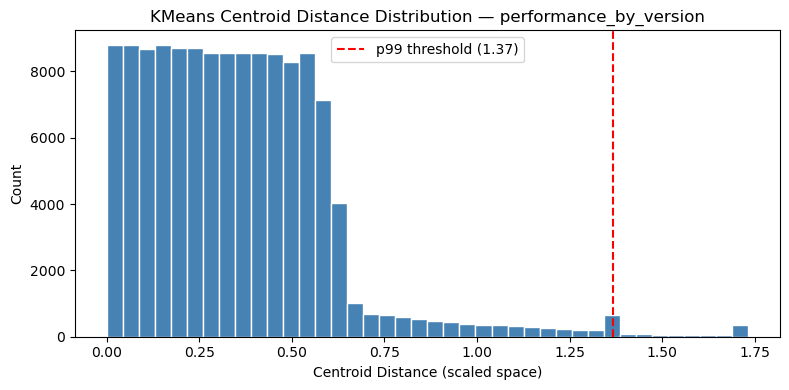

In [8]:
import matplotlib.pyplot as plt

dist_pd = predictions.select("centroid_distance").toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dist_pd["centroid_distance"], bins=40, edgecolor="white", color="steelblue")
ax.axvline(p99_dist, color="red", linestyle="--", label=f"p99 threshold ({p99_dist:.2f})")
ax.set_xlabel("Centroid Distance (scaled space)")
ax.set_ylabel("Count")
ax.set_title("KMeans Centroid Distance Distribution — performance_by_version")
ax.legend()
plt.tight_layout()
plt.show()

### Layman Explanation

This histogram shows how far each individual interaction sits from its cluster centre. Most interactions land near zero — they are "typical." The long tail to the right contains the unusual ones. The red dashed line is our chosen threshold: anything to its right was flagged as an anomaly.

A good threshold sits at a **natural gap or inflection point** in the distribution. If the line cuts through a dense region, we are splitting "normal" interactions arbitrarily. If it sits at a clear gap, the separation is meaningful. Given that the top anomalies are all 300,000ms hard-cap hits (centroid distance = 1.73), a visible gap is expected between the threshold (1.37) and the extreme tail.

### Technical Discussion

`predictions.select("centroid_distance").toPandas()` materialises only the one column needed for plotting, minimising the data transferred from Spark to the driver.

`ax.hist(..., bins=40)` creates 40 equal-width bins. For a right-skewed distribution (which centroid distances typically are), a log scale on the x-axis or a `bins` argument using quantile-based edges would reveal the tail structure more clearly.

`ax.axvline(p99_dist, ...)` marks the adaptive 99th-percentile threshold computed earlier. The combination of distribution + threshold line is a standard anomaly detection diagnostic — it shows both what is "normal" and where the boundary lies.

### Terminology

| Term | Meaning |
|------|---------|
| **Histogram** | A bar chart where each bar represents the count of values falling in a numeric range (bin). Used to visualise the shape of a distribution. |
| **Right-skewed distribution** | A distribution with a long tail extending to the right. Most values are low; a few are very high. Anomaly score distributions are typically right-skewed. |
| **p99 threshold** | The 99th percentile of the distance distribution. Only 1% of records exceed this value and are flagged as anomalies. |
| **Adaptive threshold** | A cut-off derived from the current data's distribution, as opposed to a hard-coded number. |
| **Distribution tail** | The low-probability region at the extremes of a distribution. Anomalies are expected to live in the tail. |
| **`toPandas()`** | Collects a Spark DataFrame from all executors back to the driver as a pandas DataFrame. Should only be used on small results; large collects can exhaust driver memory. |

## Cell 9 — Device-Type Breakdown of KMeans Anomalies

Cross-validate by examining whether the KMeans anomalies and Z-score anomalies
agree on which device types are most anomaly-prone.

In [9]:
# Break down KMeans anomalies by device type and compare with Z-score device anomalies.
# Both datasets now share the same individual-interaction granularity.

kmeans_by_device = (
    ml_anomalies
    .groupBy("device_type")
    .agg(
        F.count("*").alias("kmeans_anomalies"),
        F.round(F.avg("centroid_distance"), 4).alias("avg_distance"),
        F.round(F.max("centroid_distance"), 4).alias("max_distance"),
    )
    .orderBy(F.col("kmeans_anomalies").desc())
)
print("KMeans anomalies by device type:")
kmeans_by_device.show()

zscore_device_pd = pg_query("""
    SELECT device_type, COUNT(*) AS zscore_anomalies
    FROM performance_anomalies
    WHERE device_type IS NOT NULL AND app_version IS NULL
    GROUP BY device_type
    ORDER BY zscore_anomalies DESC
""")
if len(zscore_device_pd) > 0:
    print("Z-score anomalies by device type:")
    print(zscore_device_pd.to_string(index=False))
else:
    print("No device-level Z-score anomalies found in performance_anomalies.")

KMeans anomalies by device type:
+--------------+----------------+------------+------------+
|   device_type|kmeans_anomalies|avg_distance|max_distance|
+--------------+----------------+------------+------------+
|        iPhone|             519|      1.5082|      1.7318|
|          iPad|             418|       1.521|      1.7318|
| Android Phone|             256|      1.5042|      1.7318|
|Android Tablet|             200|      1.5067|      1.7318|
+--------------+----------------+------------+------------+

No device-level Z-score anomalies found in performance_anomalies.


/tmp/ipykernel_30593/1824420460.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


### Layman Explanation

The intended cross-validation — comparing KMeans and Z-score device rankings — cannot be completed: the database contains **zero device-level Z-score anomalies**. The reason is explained in the Technical Discussion below, but the short version is that Job 3 never writes device-level anomaly rows in the format this query expects.

We can still read the KMeans device breakdown on its own:

| Device | KMeans anomalies | % of 1,393 total |
|--------|-----------------|-----------------|
| iPhone | 519 | 37% |
| iPad | 418 | 30% |
| Android Phone | 256 | 18% |
| Android Tablet | 200 | 14% |

iPhone leads in count simply because it has the most interactions in the generated dataset — not because iPhone is more anomaly-prone. All four device types share nearly identical average centroid distance (~1.50) and identical maximum distance (1.7318 — the hard-cap ceiling seen in Cell 5). This uniformity means the severity of anomalies is consistent across devices; only the volume differs in proportion to overall usage.

### Technical Discussion

`ml_anomalies` already contains the full enriched-interaction row including `device_type`,
so no second model fit is needed — we simply group the already-flagged rows by device type.

**Why the Z-score device query returns zero rows:** The query filters `WHERE device_type IS NOT NULL AND app_version IS NULL`, expecting Job 3 to write separate device-level anomaly rows with a NULL `app_version`. However, Job 3's anomaly detection runs a single pass grouped by `(app_version, metric_date)` — it does not run a separate device-level detection. Every row written to `performance_anomalies` therefore has both `app_version` AND `device_type` populated. No row ever has `app_version IS NULL`, so the filter returns nothing.

To retrieve the device breakdown of Z-score anomalies from what actually exists in the table, the query should be:
```sql
SELECT device_type, COUNT(*) AS zscore_anomalies
FROM performance_anomalies
WHERE device_type IS NOT NULL
GROUP BY device_type
ORDER BY zscore_anomalies DESC
```
This would show the device mix within the existing (app_version, metric_date)-grouped anomalies rather than device-specific anomaly detections. The cross-validation would then compare KMeans device *counts* against Z-score device *counts* — a weaker test than comparing independent device-specific detections, but achievable with the current schema.

### Terminology

| Term | Meaning |
|------|---------|
| **Cross-validation** | Using a second dimension of the same dataset (here device type vs app version) to check whether a finding holds across different slices of the data. |
| **Anomaly agreement** | When two independent detection methods flag the same observations, confidence in the finding increases. Disagreement suggests one method is sensitive to noise. |
| **Granularity parity** | Training and comparing models at the same level of aggregation (individual interactions here) so that counts and overlap metrics are directly comparable. |

## Cell 10 — Cleanup

In [10]:
predictions.unpersist()
sdf.unpersist()
sdf_raw.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
